<a href="https://colab.research.google.com/github/jahnavitelsang/Assignment2026/blob/main/SVM_assignment_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Pharma_Industry (1).csv')

In [ ]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [ ]:
df.shape

(500, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [ ]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [ ]:
df.isnull().sum()

,0
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0


In [ ]:
df.duplicated().sum()

np.int64(0)

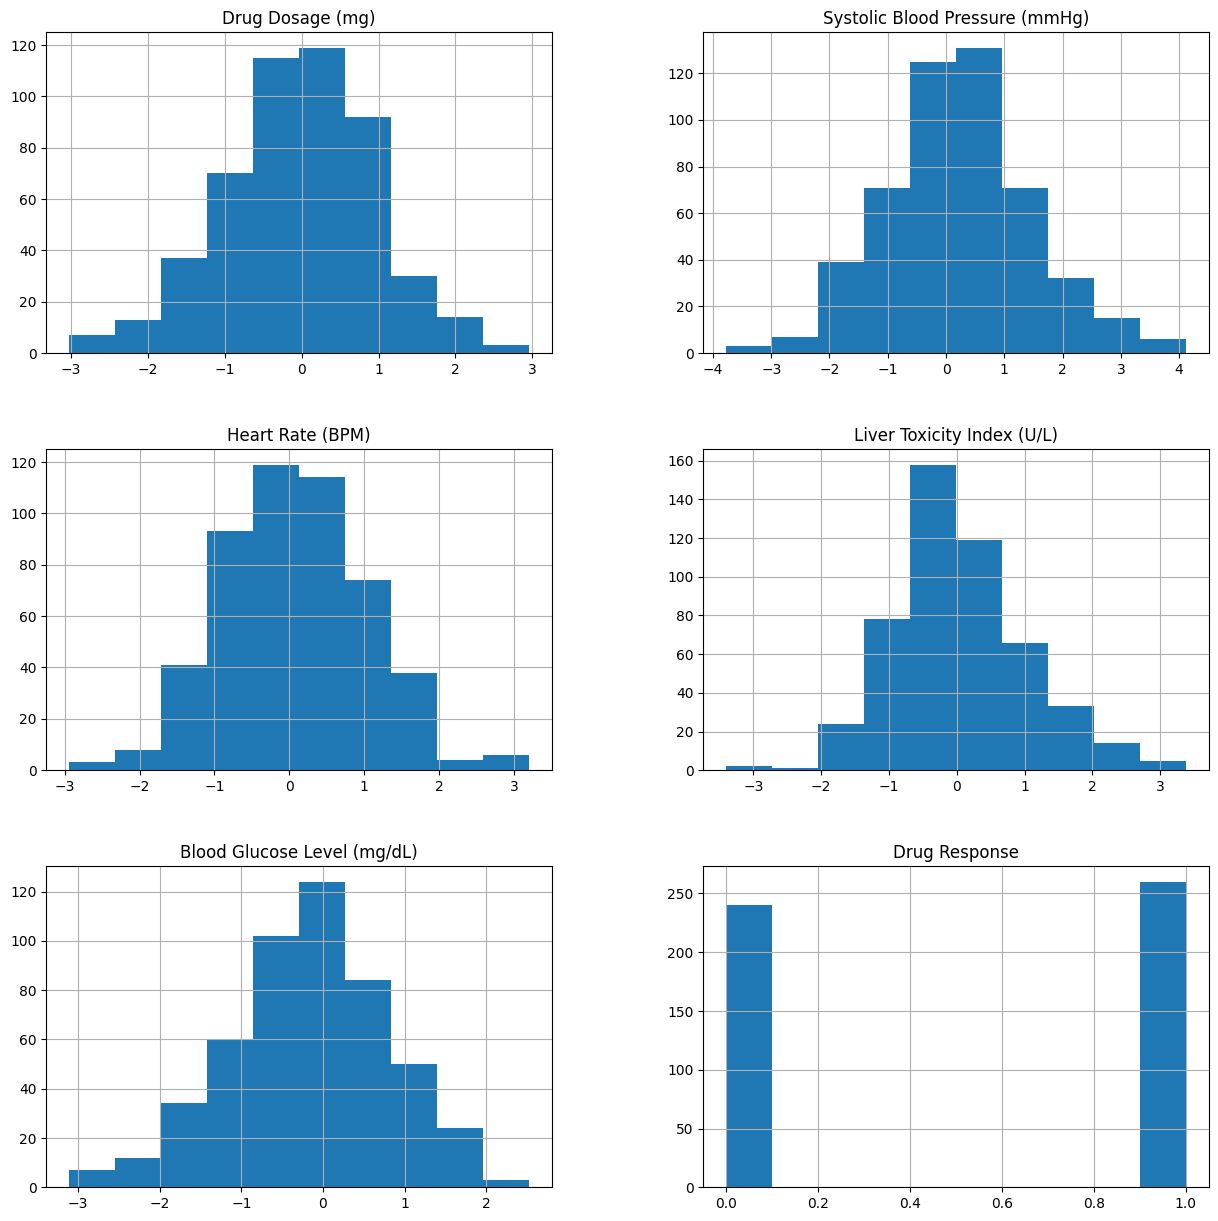

In [ ]:
df.hist(figsize=(15,15))
plt.show()

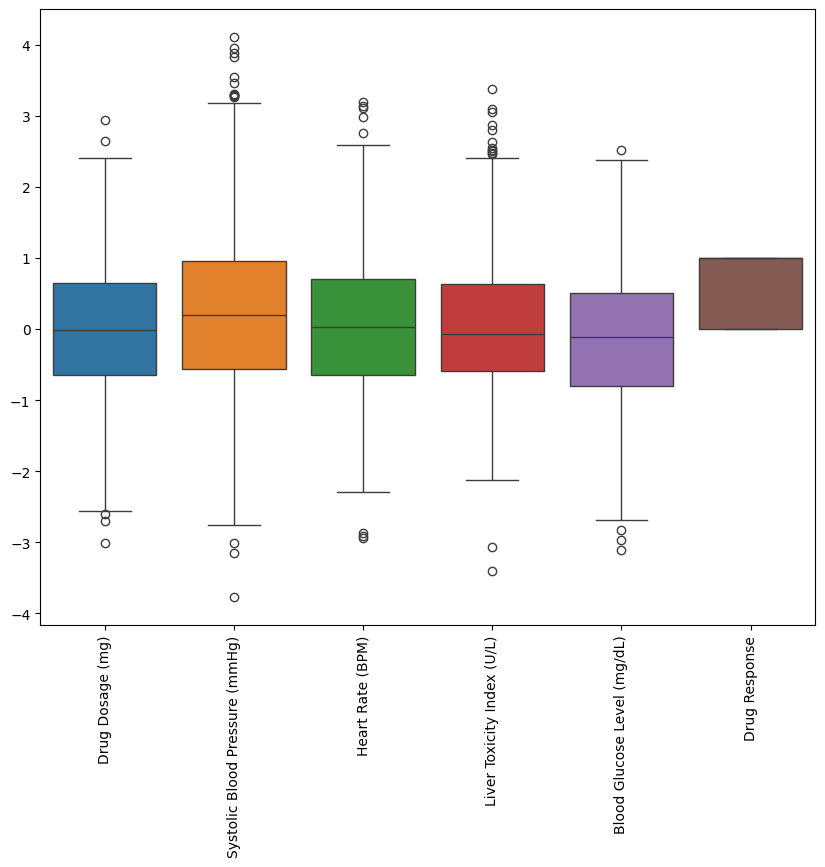

In [ ]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df)
plt.xticks(rotation = 90)
plt.show()

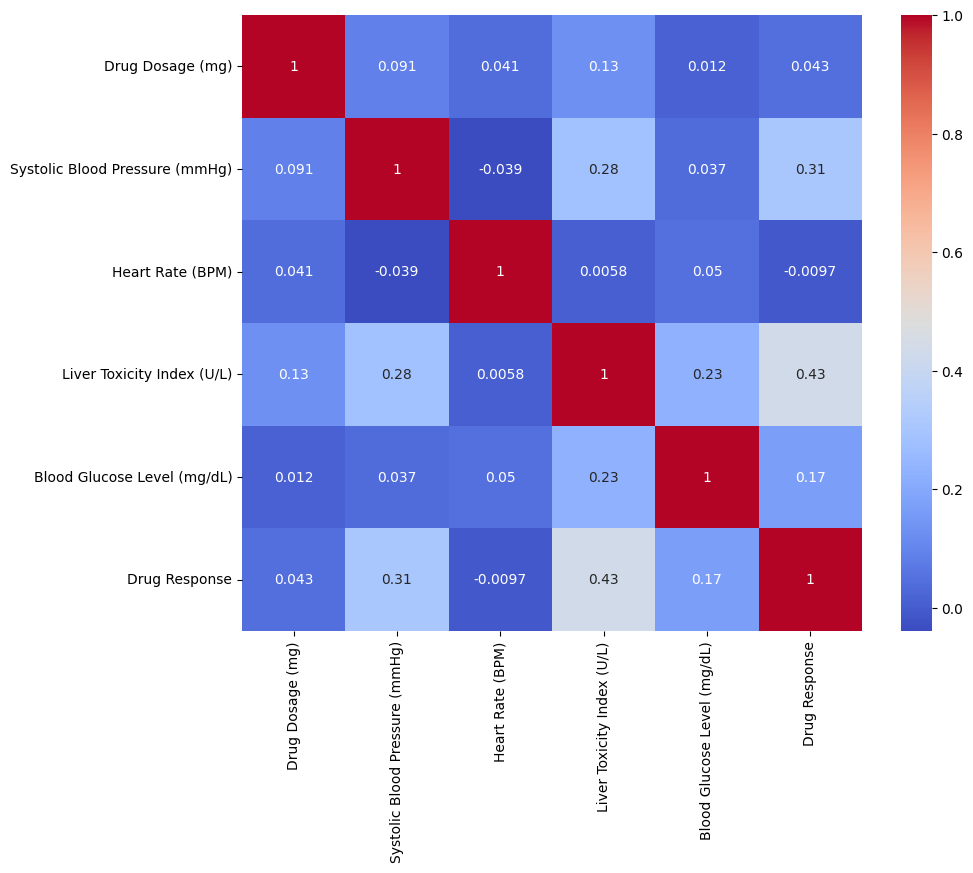

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()



In [ ]:
#correlation heatmap uncovers linear dependencies between variables (such as dosage versus toxicity or blood pressure).

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']
X

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355
4,0.377100,0.538410,-0.029263,1.896015,-0.960130
...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393
496,0.551476,1.714321,0.340589,1.712558,-0.496315
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838
498,1.661259,0.245759,-0.457096,0.633355,0.657413


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

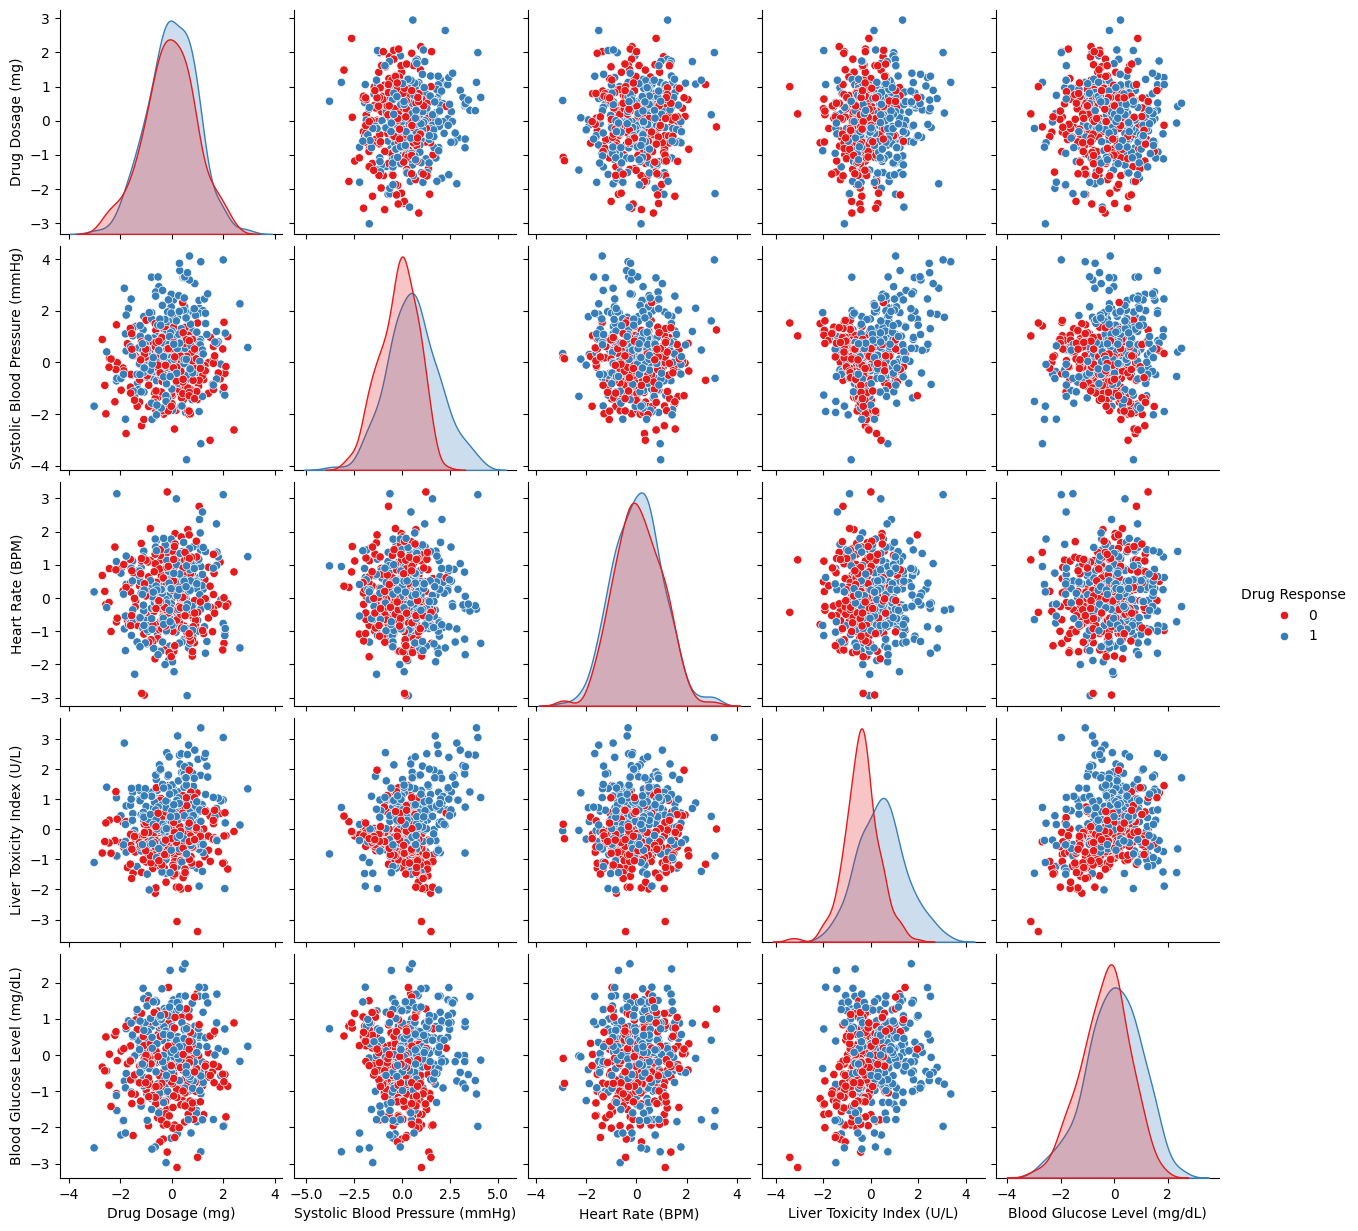

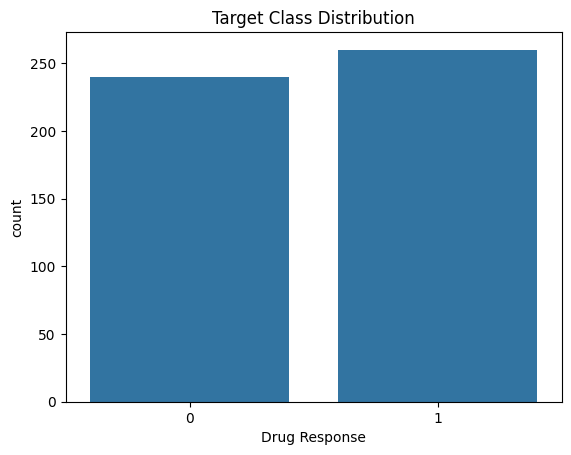

In [ ]:
sns.pairplot(df, hue='Drug Response', palette='Set1')
plt.show()

# Visualizing class balance
sns.countplot(x='Drug Response', data=df)
plt.title('Target Class Distribution')
plt.show()

In [ ]:
#Pair plots generate pairwise scatter plots across all features, color-coded by the target variable to reveal how effectively the classes separate. The count plot confirms whether the dataset suffers from class imbalance.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC


In [ ]:
#Using diff kernels
svm_linear = SVC(kernel='linear')
svm_poly = SVC(kernel='poly', degree = 3)
svm_rbf = SVC(kernel='rbf', gamma = 0.2)

In [ ]:
svm_linear = svm_linear.fit(X_train, y_train)
svm_linear_pred = svm_linear.predict(X_test)
accuracy_score(y_test, svm_linear_pred)

0.78

In [ ]:
svm_poly = svm_poly.fit(X_train, y_train)
svm_poly_pred = svm_poly.predict(X_test)
accuracy_score(y_test, svm_poly_pred)

0.69

In [ ]:
svm_rbf = svm_rbf.fit(X_train, y_train)
svm_rbf_pred = svm_rbf.predict(X_test)
accuracy_score(y_test, svm_rbf_pred)

0.83

In [ ]:
classification_report(y_test, svm_linear_pred)


'              precision    recall  f1-score   support\n\n           0       0.72      0.82      0.77        44\n           1       0.84      0.75      0.79        56\n\n    accuracy                           0.78       100\n   macro avg       0.78      0.78      0.78       100\nweighted avg       0.79      0.78      0.78       100\n'

In [ ]:
classification_report(y_test, svm_poly_pred)


'              precision    recall  f1-score   support\n\n           0       0.60      0.89      0.72        44\n           1       0.86      0.54      0.66        56\n\n    accuracy                           0.69       100\n   macro avg       0.73      0.71      0.69       100\nweighted avg       0.74      0.69      0.68       100\n'

In [ ]:
classification_report(y_test, svm_rbf_pred)

'              precision    recall  f1-score   support\n\n           0       0.79      0.84      0.81        44\n           1       0.87      0.82      0.84        56\n\n    accuracy                           0.83       100\n   macro avg       0.83      0.83      0.83       100\nweighted avg       0.83      0.83      0.83       100\n'

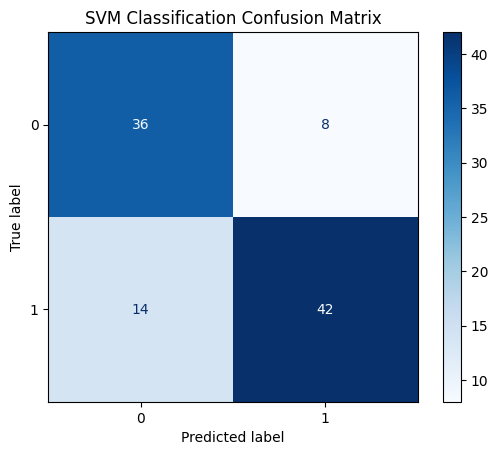

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(svm_linear, X_test, y_test, cmap=plt.cm.Blues)
plt.title('SVM Classification Confusion Matrix')
plt.show()

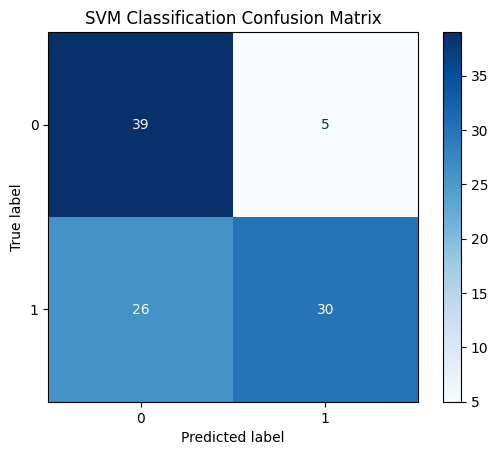

In [ ]:
ConfusionMatrixDisplay.from_estimator(svm_poly, X_test, y_test, cmap=plt.cm.Blues)
plt.title('SVM Classification Confusion Matrix')
plt.show()

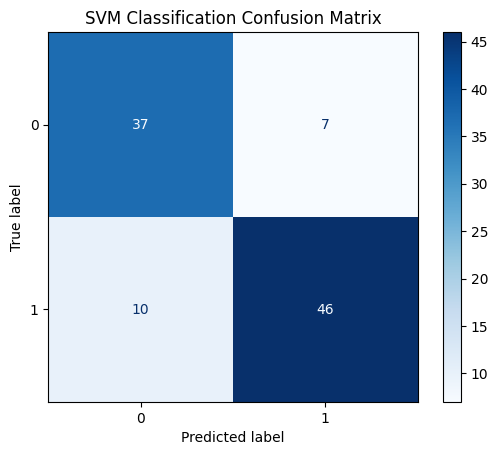

In [ ]:
ConfusionMatrixDisplay.from_estimator(svm_rbf, X_test, y_test, cmap=plt.cm.Blues)
plt.title('SVM Classification Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 0.2, 1, 'scale'],
    'kernel': ['rbf', 'linear']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=5)

# Fit to training data
grid_search.fit(X_train, y_train)

# Output best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Optimized Test Accuracy:", test_accuracy)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.

In [ ]:

# Linear Kernel: Reached 78% accuracy. It provides a solid baseline because some clinical metrics show mild linear separability, but it lacks the flexibility to capture intricate boundaries.
#Radial Basis Function (RBF) Kernel:Achieved the highest accuracy (83%) with balanced precision and recall for both classes. It effectively captures the complex, non-linear interactions across the pharmaceutical attributes.
#Polynomial Kernel: Underperformed at 69% accuracy with low recall (0.54) for the positive drug response class, indicating vulnerability to overfitting on this feature space.


In [ ]:
#Strengths:The dataset's clean numerical values (zero missing values, well-scaled distributions) allow SVM algorithms to construct robust hyperplanes without extensive data imputation.
#Weaknesses:Because SVM relies heavily on geometric distance metrics, unscaled outliers or correlated vital signs (e.g., blood pressure and heart rate) can occasionally skew the decision boundary if not properly regularized.

In [ ]:
# Clinical Decision Support:High-performing models like the RBF-SVM help clinicians evaluate patient physiological profiles to predict drug responses and mitigate adverse side effects.
# Interpretability vs. Accuracy:** While the RBF kernel offers superior accuracy, its black-box nature necessitates supplementary interpretability frameworks (such as SHAP values) before deployment in high-stakes medical environments.